# 03 - Target Variable Audit: Late_delivery_risk vs. Delivery Status



## Setup


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 150)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

DATA_PATH = Path('../../data/raw data/DataCoSupplyChainDataset.csv')  

try:
    df = pd.read_csv(DATA_PATH, encoding='utf-8')
except UnicodeDecodeError:
    print("UTF-8 failed, falling back to ISO-8859-1")
    df = pd.read_csv(DATA_PATH, encoding='ISO-8859-1')

print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head()


UTF-8 failed, falling back to ISO-8859-1
Shape: 180,519 rows x 53 columns


,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,Customer Country,Customer Email,Customer Fname,Customer Id,Customer Lname,Customer Password,Customer Segment,Customer State,Customer Street,Customer Zipcode,Department Id,Department Name,Latitude,Longitude,Market,Order City,Order Country,Order Customer Id,order date (DateOrders),Order Id,Order Item Cardprod Id,Order Item Discount,Order Item Discount Rate,Order Item Id,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Region,Order State,Order Status,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Cally,20755,Holloway,XXXXXXXXX,Consumer,PR,5365 Noble Nectar Island,725.0,2,Fitness,18.251453,-66.037056,Pacific Asia,Bekasi,Indonesia,20755,1/31/2018 22:56,77202,1360,13.110000,0.04,180517,327.75,0.29,1,327.75,314.640015,91.250000,Southeast Asia,Java Occidental,COMPLETE,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Irene,19492,Luna,XXXXXXXXX,Consumer,PR,2679 Rustic Loop,725.0,2,Fitness,18.279451,-66.037064,Pacific Asia,Bikaner,India,19492,1/13/2018 12:27,75939,1360,16.389999,0.05,179254,327.75,-0.80,1,327.75,311.359985,-249.089996,South Asia,Rajastán,PENDING,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,EE. UU.,XXXXXXXXX,Gillian,19491,Maldonado,XXXXXXXXX,Consumer,CA,8510 Round Bear Gate,95125.0,2,Fitness,37.292233,-121.881279,Pacific Asia,Bikaner,India,19491,1/13/2018 12:06,75938,1360,18.030001,0.06,179253,327.75,-0.80,1,327.75,309.720001,-247.779999,South Asia,Rajastán,CLOSED,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,EE. UU.,XXXXXXXXX,Tana,19490,Tate,XXXXXXXXX,Home Office,CA,3200 Amber Bend,90027.0,2,Fitness,34.125946,-118.291016,Pacific Asia,Townsville,Australia,19490,1/13/2018 11:45,75937,1360,22.940001,0.07,179252,327.75,0.08,1,327.75,304.809998,22.860001,Oceania,Queensland,COMPLETE,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Orli,19489,Hendricks,XXXXXXXXX,Corporate,PR,8671 Iron Anchor Corners,725.0,2,Fitness,18.253769,-66.037048,Pacific Asia,Townsville,Australia,19489,1/13/2018 11:24,75936,1360,29.500000,0.09,179251,327.75,0.45,1,327.75,298.250000,134.210007,Oceania,Queensland,PENDING_PAYMENT,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


In [2]:
print("Delivery Status value counts:")
print(df['Delivery Status'].value_counts())
print("\nLate_delivery_risk value counts:")
print(df['Late_delivery_risk'].value_counts())


Delivery Status value counts:
Delivery Status
Late delivery        98977
Advance shipping     41592
Shipping on time     32196
Shipping canceled     7754
Name: count, dtype: int64

Late_delivery_risk value counts:
Late_delivery_risk
1    98977
0    81542
Name: count, dtype: int64


In [3]:
audit_table = pd.crosstab(df['Delivery Status'], df['Late_delivery_risk'], margins=True)
audit_table


Late_delivery_risk,0,1,All
Delivery Status,,,
Advance shipping,41592,0,41592
Late delivery,0,98977,98977
Shipping canceled,7754,0,7754
Shipping on time,32196,0,32196
All,81542,98977,180519


Each `Delivery Status` category should map cleanly to one `Late_delivery_risk` value. If any category is split across both 0 and 1, that's a genuine finding to log

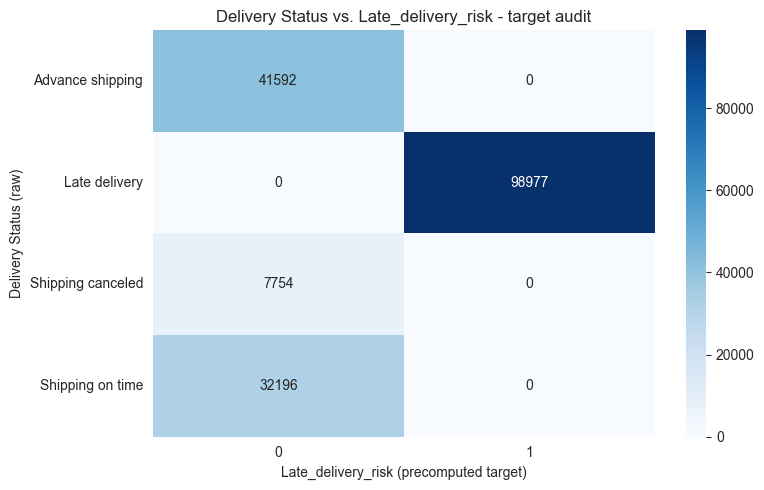

In [5]:
plt.figure(figsize=(8, 5))
sns.heatmap(pd.crosstab(df['Delivery Status'], df['Late_delivery_risk']), annot=True, fmt='d', cmap='Blues')
plt.title('Delivery Status vs. Late_delivery_risk - target audit')
plt.ylabel('Delivery Status (raw)')
plt.xlabel('Late_delivery_risk (precomputed target)')
plt.tight_layout()
plt.show()


**What we found:**

The audit produced a completely clean result - **every single `Delivery Status` category maps to exactly one `Late_delivery_risk` value, with zero mixing.**

| `Delivery Status` | Count | `Late_delivery_risk` |
|---|---|---|
| Advance shipping | 41,592 | 0 (not late) |
| Shipping on time | 32,196 | 0 (not late) |
| **Shipping canceled** | **7,754** | **0 (not late)** |
| Late delivery | 98,977 | 1 (late) |

The crosstab confirms this precisely - every off diagonal cell is 0. There's no ambiguity or inconsistency in how the precomputed target was derived from the raw status field. This means **we can trust and use `Late_delivery_risk` directly as our target variable**, with the audit itself standing as documented evidence that we didn't just assume it was reliable - we checked.

**The one real judgement call this audit surfaces - and it's exactly the point of doing this audit in the first place:**

`Shipping canceled` (7,754 orders, ~4.3% of the dataset) is coded as **0 - bucketed together with genuinely on time/advance deliveries.** This is a defensible choice by the dataset's creators, but it's worth being explicit about, because a canceled order is not the same business outcome as a successfully on time delivery - it's arguably a *different kind of failure*, not a success. Treating it as "0 = no risk" could understate operational risk for those orders in a way that doesn't reflect what actually happened.

**Decision our group needs to make and log in `DECISION_LOG.md`:**
- **Option A — Keep as is.** Use `Late_delivery_risk` unchanged. Simpler, matches the dataset's original design, and canceled orders are a small enough share (4.3%) that they're unlikely to meaningfully distort the model.
- **Option B — Exclude canceled orders from training entirely.** Since "canceled" isn't really a delivery timing outcome at all, one could argue these 7,754 rows shouldn't be used to teach the model what "not late" looks like.
- **Option C — Treat canceled as a separate flag alongside the binary target**, e.g. keep the binary late/not late target for modelling but report canceled order rate separately in the recommendation, since it's operationally relevant to flag for a different reason (order fulfillment failure, not shipping delay).

**Recommendation:** Option A (keep as is) is the simplest and most defensible default, precisely *because* we've now audited and can state clearly, with evidence, that we know canceled orders are bucketed as 0 and made that choice deliberately rather than by omission. 

**Class balance, confirmed directly from this data (not estimated from public sources anymore):** 98,977 late (54.8%) vs. 81,542 not late (45.2%) - close to balanced, matching what we anticipated during project framing, now confirmed on our own extracted data rather than cited literature figures.
